In [70]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal


In [85]:
class QuadricEquationState(TypedDict):
    a: int
    b: int
    c: int

    equation_preview: str
    discriminant: float
    roots: tuple



In [89]:
def resolve_sign(number: int) -> str:
    if number < 0:
        return f"- {number*-1}"
    else:
        return f"+ {number}" 

def equation_preview(state: QuadricEquationState) -> QuadricEquationState:
    a, b, c = state['a'], state['b'], state['c']

    equation = f"{a}x\u00b2 {resolve_sign(b)}x {resolve_sign(c)}"

    return {"equation_preview" : equation}

def discriminant(state: QuadricEquationState) -> QuadricEquationState:
    a, b, c = state['a'], state['b'], state['c']
    d = b**2 - (4*a*c)
    
    return {"discriminant": d}

def two_roots(state: QuadricEquationState) -> QuadricEquationState:
    a, b, c, d = state['a'], state['b'], state['c'], state['discriminant']
    root1 = (-b + d**0.5)/(2*a)
    root2 = (-b - d**0.5)/(2*a)

    return {'roots': (root1, root2)}

def one_root(state:QuadricEquationState)->QuadricEquationState:
    a, b, c, d = state['a'], state['b'], state['c'], state['discriminant']
    root = (-b)/(2*a)

    return {'roots': (root,)}

def no_roots(state: QuadricEquationState) -> QuadricEquationState:
    return {'roots': ()}


def root_method_selection(state: QuadricEquationState) -> Literal['two_roots', 'one_root', 'no_roots']:
    d = state['discriminant']

    if d > 0:
        return 'two_roots'
    elif d == 0:
        return "one_root"
    else:
        return "no_roots"

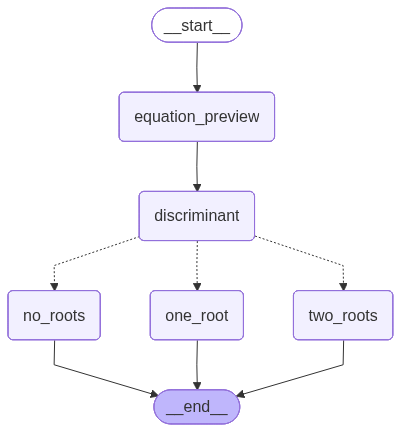

In [90]:
graph = StateGraph(QuadricEquationState)

# Add Nodes
graph.add_node("equation_preview", equation_preview)
graph.add_node("discriminant", discriminant)
graph.add_node('two_roots', two_roots)
graph.add_node('one_root', one_root)
graph.add_node('no_roots', no_roots)


graph.add_edge(START, 'equation_preview')
graph.add_edge('equation_preview', 'discriminant')
graph.add_conditional_edges('discriminant', root_method_selection)
graph.add_edge('two_roots', END)
graph.add_edge('one_root', END)
graph.add_edge('no_roots', END)




workflow = graph.compile()
workflow



In [91]:
initial_state = {
    "a": 20,
    "b": -1,
    "c": 5
}

final_state = workflow.invoke(initial_state)
final_state

{'a': 20,
 'b': -1,
 'c': 5,
 'equation_preview': '20x² - 1x + 5',
 'discriminant': -399,
 'roots': ()}